# Energy usage analysis 

In [12]:
%matplotlib inline
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

from pandas import DataFrame, read_csv

from typing import cast

import src.machines as machines
import src.programs as programs
import src.energyuq as energyuq

from easyvvuq.analysis.sc_analysis import SCAnalysisResults

In [16]:
def parse_dakota_file(file_path: str) -> DataFrame:
    with open(file_path, 'r') as f:
        headers = f.readline().replace('%', '').strip().split()
        
        df = read_csv(f, sep=r'\s+', names=headers, header=None)
    return df

dakota_result = parse_dakota_file("pce_samples.dat")
qoi = "energy_uj"

In [101]:
from typing import NamedTuple


class limit(NamedTuple):
    lower: int # | float
    upper: int # | float


machine = machines.Glados
limits={
    "N_THREADS": limit(1, machine.physical_core_count),
    "CLK": limit(0, len(machine.freq) - 1)
}
labels = list(limits.keys())
values = list(limits.values())

import matplotlib.colors as mcolors


def colors_for(qoi) -> dict[str, tuple[str,str,str,str]]:
    return {
        'high_low': ('#0000ff', f'lower {qoi}', '#ff0000', f'higher {qoi}'),
        'highest_lowest': ( '#00ffff', f'lowest {qoi}', '#00ffff00', f'highest {qoi}'),
    }


def draw_gradients(*color_list):
    n_items = len(color_list)
    
    # 1. Dynamically scale the figure height based on the number of gradients
    fig, ax = plt.subplots(figsize=(6, 0.9 * n_items + 0.4))
    
    # 2. Style the outer axis frame to look exactly like a legend box
    ax.set_facecolor('#ffffff')             # Pure white background (or '#f8f9fa' for off-white)
    for spine in ax.spines.values():
        spine.set_color('#cccccc')          # Classic light-gray legend border
        spine.set_linewidth(1.0)
        
    # Hide default coordinate numbers and tick markers
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # 3. Set structural padding limits inside the box
    ax.set_xlim(-0.06, 1.06)
    ax.set_ylim(-0.2, n_items)
    
    # Base array to map values from 0.0 to 1.0 horizontally
    gradient_base = np.linspace(0, 1, 256).reshape(1, -1)
    
    # 4. Loop backwards to draw entries from top to bottom
    for i, (color_a, label_a, color_b, label_b) in enumerate(reversed(color_list)):
        # Calculate proportional vertical placements
        y_bottom = i * 1.0
        y_top = y_bottom + 0.28
        
        # Create the custom color ramp
        cmap = mcolors.LinearSegmentedColormap.from_list(f"legend_cmap_{i}", [color_a, color_b])
        
        # Draw the linear gradient block
        ax.imshow(gradient_base, aspect='auto', cmap=cmap, extent=(0, 1, y_bottom, y_top))
        
        # Place text labels cleanly right above the edges of the gradient block
        ax.text(0.0, y_top + 0.05, label_a, ha='left', va='bottom', fontsize=10, color='#333333')
        ax.text(1.0, y_top + 0.05, label_b, ha='right', va='bottom', fontsize=10, color='#333333')
        
    # plt.tight_layout()
    # plt.show()

def plot_sorted(dataframe, qoi):
    ### por que eres assim???????
    column_key = qoi
    sorted_dataframe: DataFrame = dataframe.sort_values(by=column_key, ascending=False)

    plt.semilogy(sorted_dataframe[column_key].to_numpy())
    plt.title(f"{qoi} sorted")
    plt.show()

def get_confidence_intervals(samples, conf=0.9):
    """
    Compute the confidence intervals given an array of samples

    Parameters
    ----------
    samples : array
        Samples on which to compute the intervals.
    conf : float, optional, must be in [0, 1].
        The confidence interval percentage. The default is 0.9.

    Returns
    -------
    lower : array
        The lower confidence bound..
    upper : array
        The upper confidence bound.

    """

    # ake sure conf is in [0, 1]
    if conf < 0.0 or conf > 1.0:
        print('conf must be specified within [0, 1]')
        return

    # lower bound = alpha, upper bound = 1 - alpha
    alpha = 0.5 * (1.0 - conf)

    # arrays for lower and upper bound of the interval
    n_samples = samples.shape[0]
    N_qoi = samples.shape[1]
    lower = np.zeros(N_qoi)
    upper = np.zeros(N_qoi)

    # the probabilities of the ecdf
    prob = np.linspace(0, 1, n_samples)
    # the closest locations in prob that correspond to the interval bounds
    idx0 = np.where(prob <= alpha)[0][-1]
    idx1 = np.where(prob <= 1.0 - alpha)[0][-1]

    # for every location of qoi compute the ecdf-based confidence interval
    for i in range(N_qoi):
        # the sorted surrogate samples at the current location
        samples_sorted = np.sort(samples[:, i])
        # the corresponding confidence interval
        lower[i] = samples_sorted[idx0]
        upper[i] = samples_sorted[idx1]

    return lower, upper


def plot_2D_single_dimension(df, qoi):
    L = len(labels)
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R), layout="constrained")
    fig.supylabel(f"For {qoi}")

    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i].upper - values[i].lower
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i].lower - xd/10, values[i].upper + xd/10],
                                  xlabel=labels[i], ylabel=qoi
                    )
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=values[i]))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    for i in range(L):
        ax[i].scatter(df[labels[i]], df[qoi])
    
    # plt.tight_layout()

def plot_boxplot(df, qoi):
    L = len(labels)
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R), layout="constrained")
    fig.supylabel(f"For {qoi}")
    
    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i].upper - values[i].lower
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i].lower - xd/10, values[i].upper + xd/10],
                                  xlabel=labels[i], ylabel=qoi
                    )
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=values[i]))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    for i in range(L):
        qoi_c = qoi
        label_c = labels[i]
        box_frame = df[[qoi_c, label_c]].groupby(by=label_c)[[qoi_c]].apply(lambda x: x[qoi_c].to_numpy()) # pyright: ignore[reportArgumentType, reportCallIssue]

        VP = ax[i].boxplot(box_frame.to_numpy(),
                            positions=box_frame.index.to_numpy(),
                            patch_artist=True,
                            showmeans=False, showfliers=False, manage_ticks = False,
                            medianprops={"color": "white", "linewidth": 0.5},
                            boxprops={"facecolor": "C0", "edgecolor": "white", "linewidth": 0.5},
                            whiskerprops={"color": "C0", "linewidth": 1.5},
                            capprops={"color": "C0", "linewidth": 1.5}
                        )

    # plt.tight_layout()

def plot_grid_2D_best(df: DataFrame, qoi: str):
    pretty_colors = colors_for(qoi)
    L = (len(labels)+1)//2
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R), layout="constrained")
    fig.supylabel(f"Configurations evaluated by {qoi}")

    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i*2].upper - values[i*2].lower
        yd = values[i*2+1].upper - values[i*2+1].lower
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i*2].lower - xd/10, values[i*2].upper + xd/10],
                                  ylim=[values[i*2+1].lower - yd/10, values[i*2+1].upper + yd/10], 
                                  xlabel=labels[i*2], ylabel=labels[i*2+1])
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=True))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    ### por que eres assim???????
    column_key = qoi
    dataframe: DataFrame = df.sort_values(by=column_key, ascending=False)
    
    dataframe[f"{qoi}_norm"] = ((column := dataframe[qoi]) - column.min()) / (column.max() - column.min())

    s = dataframe[f"{qoi}_norm"].size

    
    cmap = mcolors.LinearSegmentedColormap.from_list("ba", list(pretty_colors['high_low'][::2]))

    def make_color(i, y):
        highest_color = cmap(y)
        lowest_color=pretty_colors['highest_lowest'][0]
        l = [lowest_color, highest_color]
        return mcolors.LinearSegmentedColormap.from_list("bui", l)(1 - (i / s))


    colors = [ make_color(i,y) for i, y in enumerate(dataframe[f"{qoi}_norm"].to_numpy())]

    more_red = Line2D([0], [0], color='red', lw=2, marker="o", linestyle='')
    more_blue = Line2D([0], [0], color='blue', lw=2, marker="o", linestyle='')
    more_cyan = Line2D([0], [0], color='cyan', lw=2, marker="o", linestyle='')
    legend_handles = [more_red, more_blue, more_cyan]
    legend_labels = ["Higher energy use", "Lesser energy use", "Among the best when ordered"]

    for i in range(L):
        xs = dataframe[labels[i*2]].to_numpy()
        ys = dataframe[labels[i*2 + 1]].to_numpy()
        # ax[i].legend(handles=legend_handles, labels=legend_labels, draggable=True, fontsize='x-small', ncols=2, bbox_to_anchor=(1, 1, 0.5, .1), loc='upper right')
        ax[i].scatter(xs, ys, c=colors)
    
    # plt.tight_layout()


## Plots

1. Which configurations consumed less energy in total and which took less time

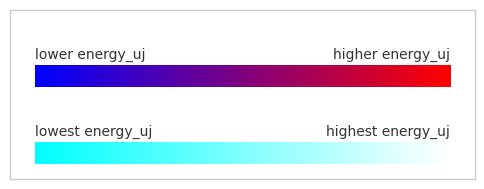

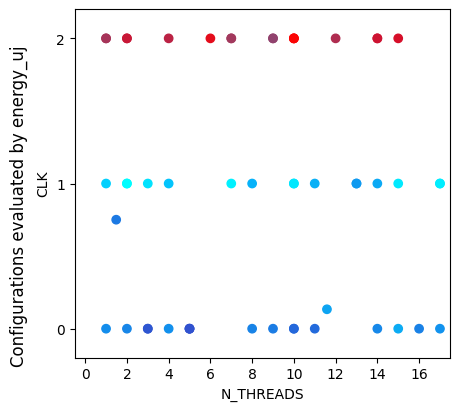

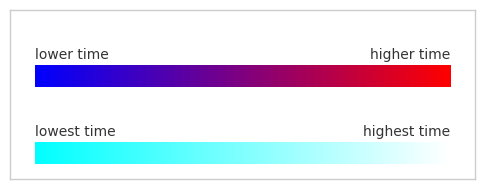

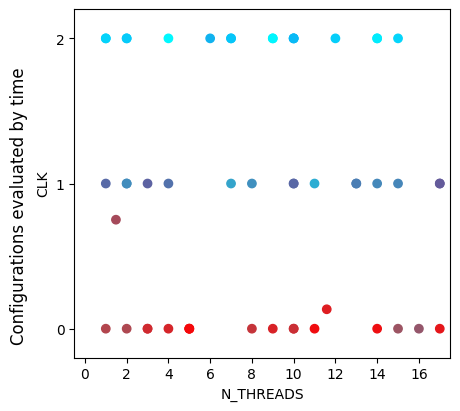

In [102]:
draw_gradients(*colors_for(qoi).values())
plot_grid_2D_best(dakota_result, qoi)
draw_gradients(*colors_for("time").values())
plot_grid_2D_best(dakota_result, "time")

3. What is the difference between the best and worst configurations?

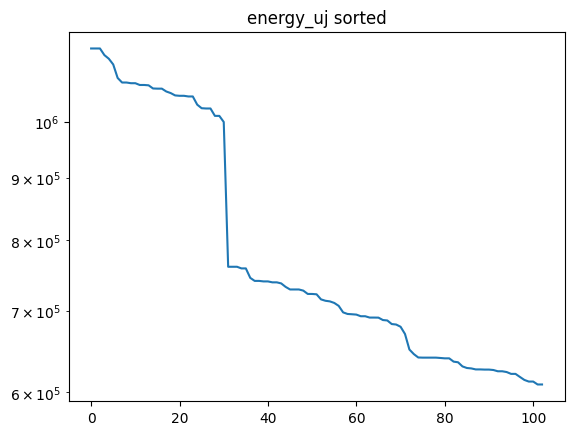

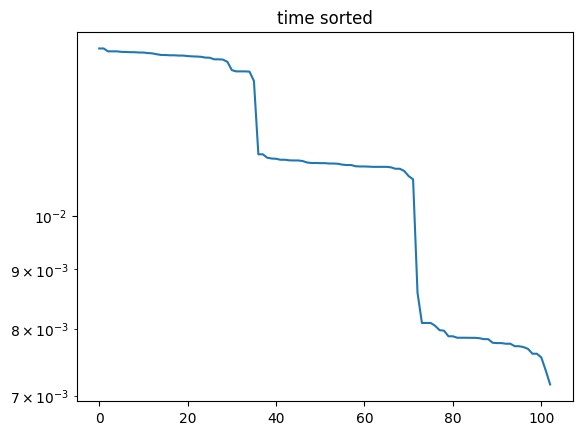

In [104]:
plot_sorted(dakota_result, qoi)
plot_sorted(dakota_result, "time")

4. View of the resulting energy usage against each parameter

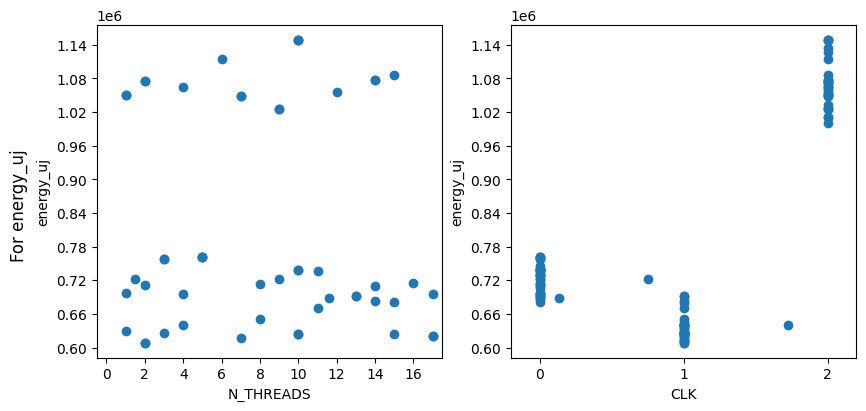

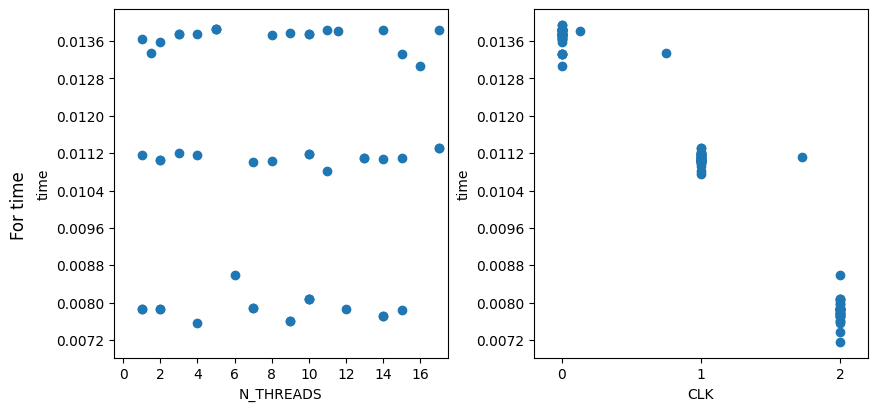

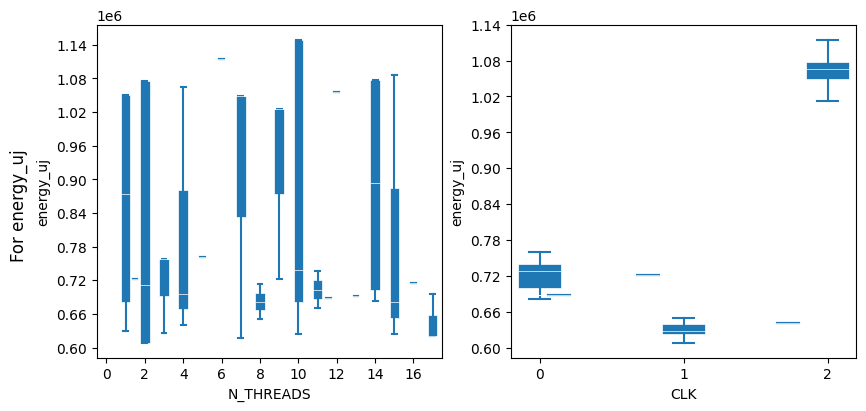

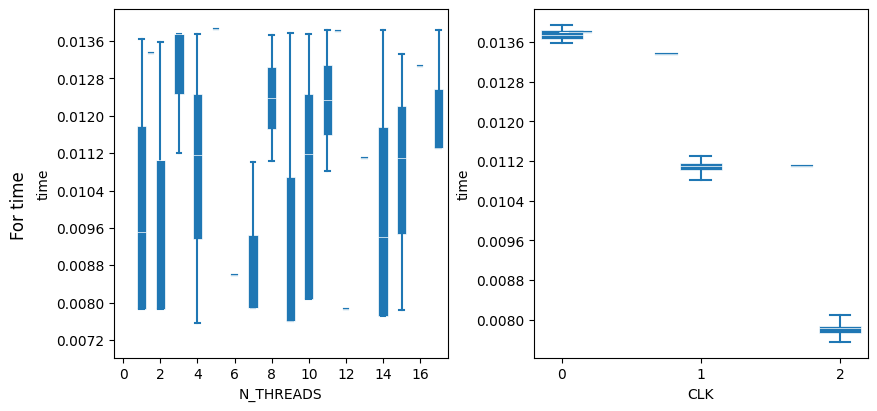

In [105]:
plot_2D_single_dimension(dakota_result, qoi)
plot_2D_single_dimension(dakota_result, "time")
plot_boxplot(dakota_result, qoi)
plot_boxplot(dakota_result, "time")